## Problem Statement

### Context

AllLife Bank is a mid-sized, fast-growing US-based financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income.

It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers.

Last year’s pilot campaign achieved a 9% conversion rate, validating the potential of this strategy. However, to optimize marketing spend and improve efficiency, the retail marketing department requires a more data-driven approach. Enhancing the success ratio of these campaigns is critical for sustainable growth and maximizing customer lifetime value.

### Objective

The objective is to develop a predictive classification model that identifies patterns and key factors driving personal loan adoption among existing liability customers. By uncovering the demographic and behavioral drivers of loan conversion, the goal is to enable targeted segmentation and more precise marketing interventions that improve campaign conversion rates, optimize marketing spend, and enhance overall profitability through higher-quality loan portfolio growth.

### Data Dictionary

* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for scaling numerical features
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering
from sklearn.cluster import KMeans

# to perform silhouette analysis
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [3]:
data = pd.read_csv('Loan_Modelling.csv')

## Data Overview

* Observations
* Sanity checks

In [4]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [6]:
data.shape

(5000, 14)

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [9]:
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [10]:
data.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis.

EDA is a critical step in any data project used to investigate and understand the data before model construction.

The following questions serve as a starting point to help you approach the analysis and generate initial insights:

**Questions**:
1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their education?
5. How does a customer's interest in purchasing a loan vary with their age?

**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

<Axes: xlabel='ID', ylabel='Count'>

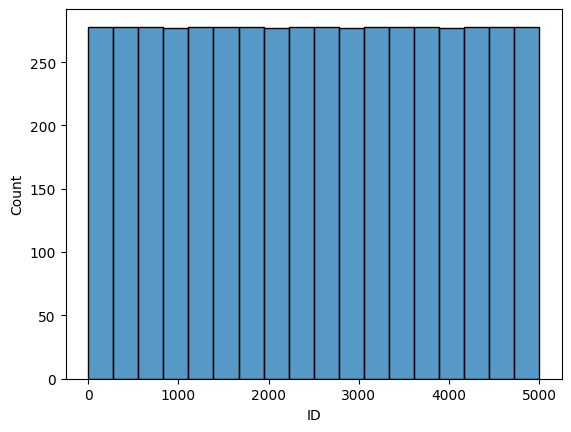

In [15]:
sns.histplot(data=data, x='ID')

ID is uniformaly distributed and it goes from 1 to 5000. ID is a redundant field for this analysis so it can be dropped.

In [16]:
data.drop('ID', axis=1, inplace=True)

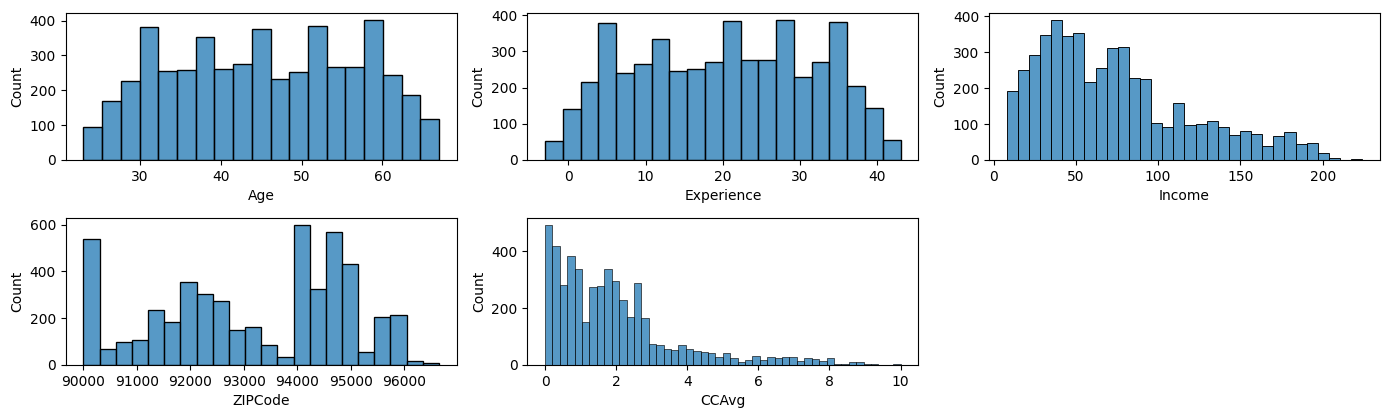

In [11]:
# defining the figure size
plt.figure(figsize=(14, 10))

# plotting the histogram for each numerical feature
for i, feature in enumerate(['Age','Experience','Income','ZIPCode', 'CCAvg']):
    plt.subplot(5, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

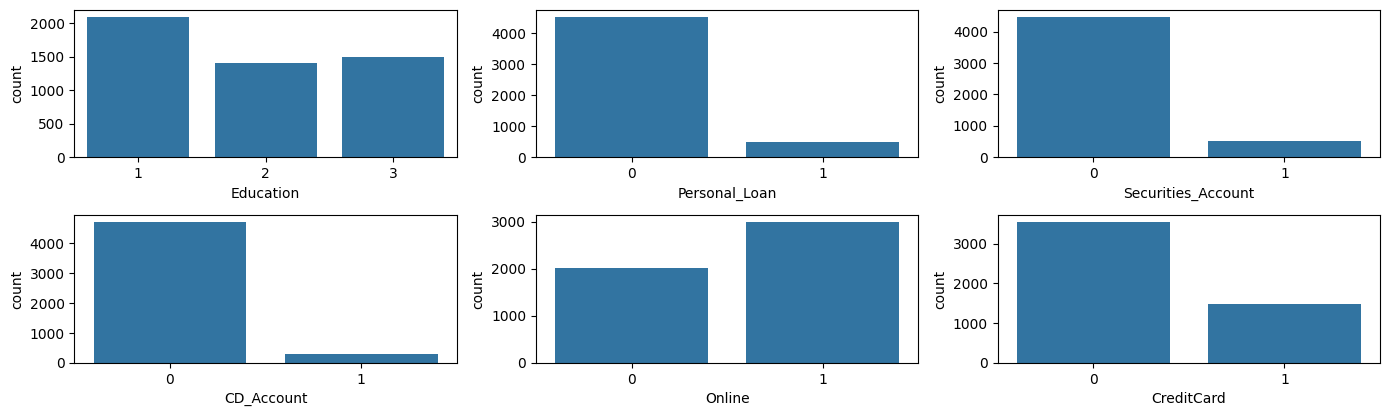

In [12]:
# defining the figure size
plt.figure(figsize=(14, 10))

# plotting the histogram for each numerical feature
for i, feature in enumerate(['Education', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard']):
    plt.subplot(5, 3, i+1)    # assign a subplot in the main plot
    sns.countplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

In [17]:
data.columns

Index(['Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='object')

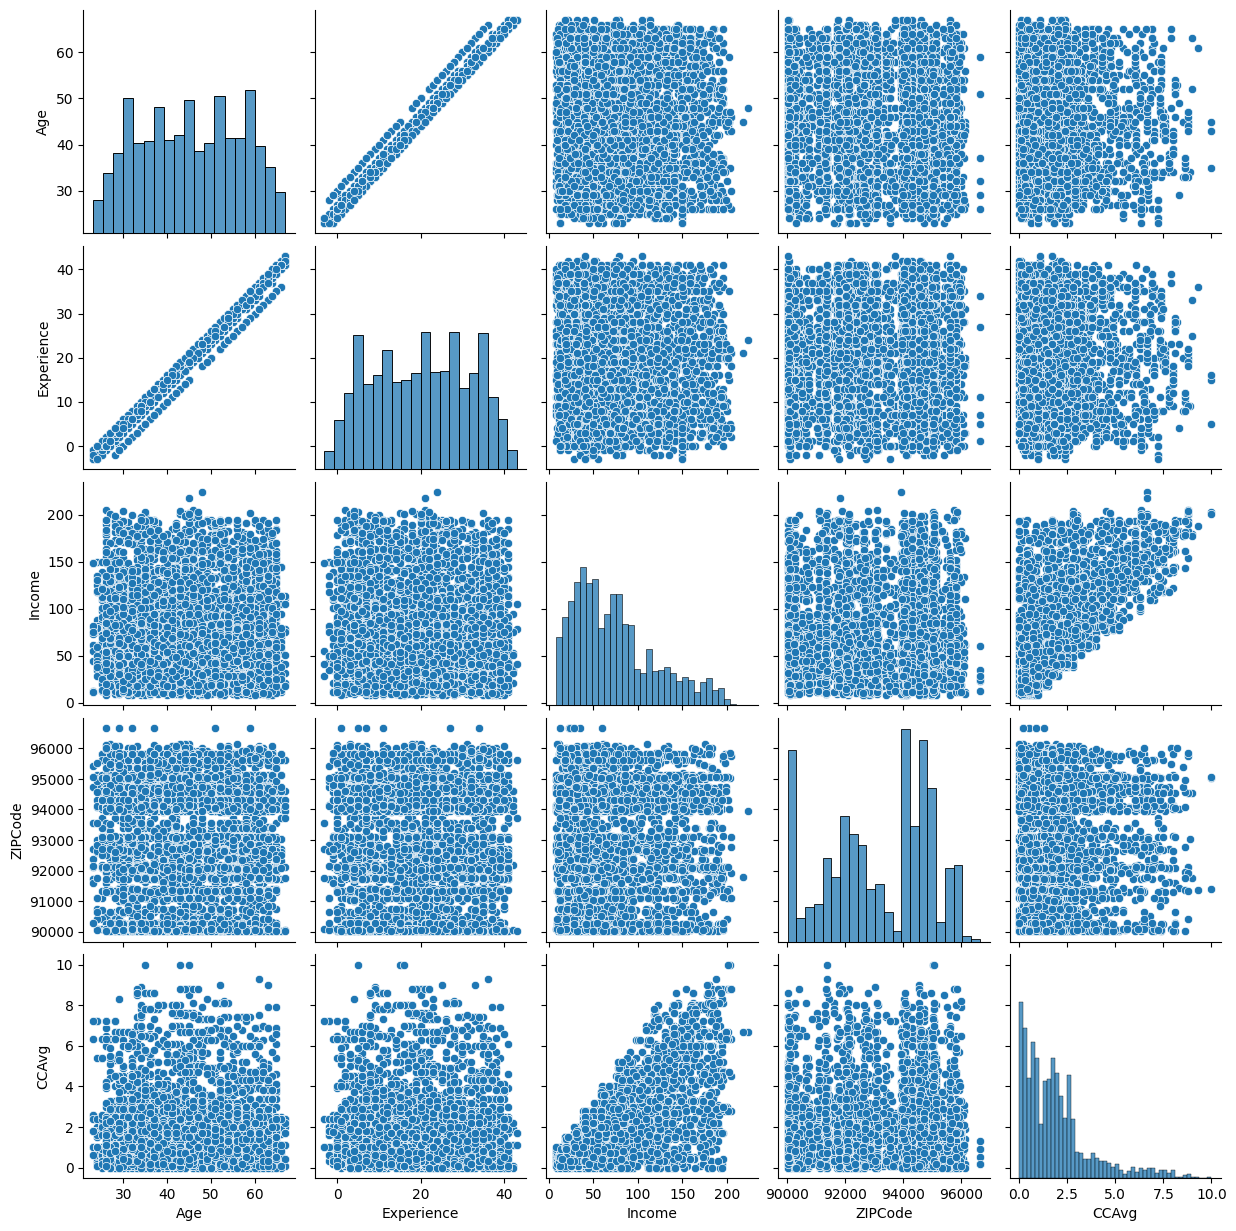

In [19]:
sns.pairplot(data[['Age','Experience','Income','ZIPCode', 'CCAvg']])

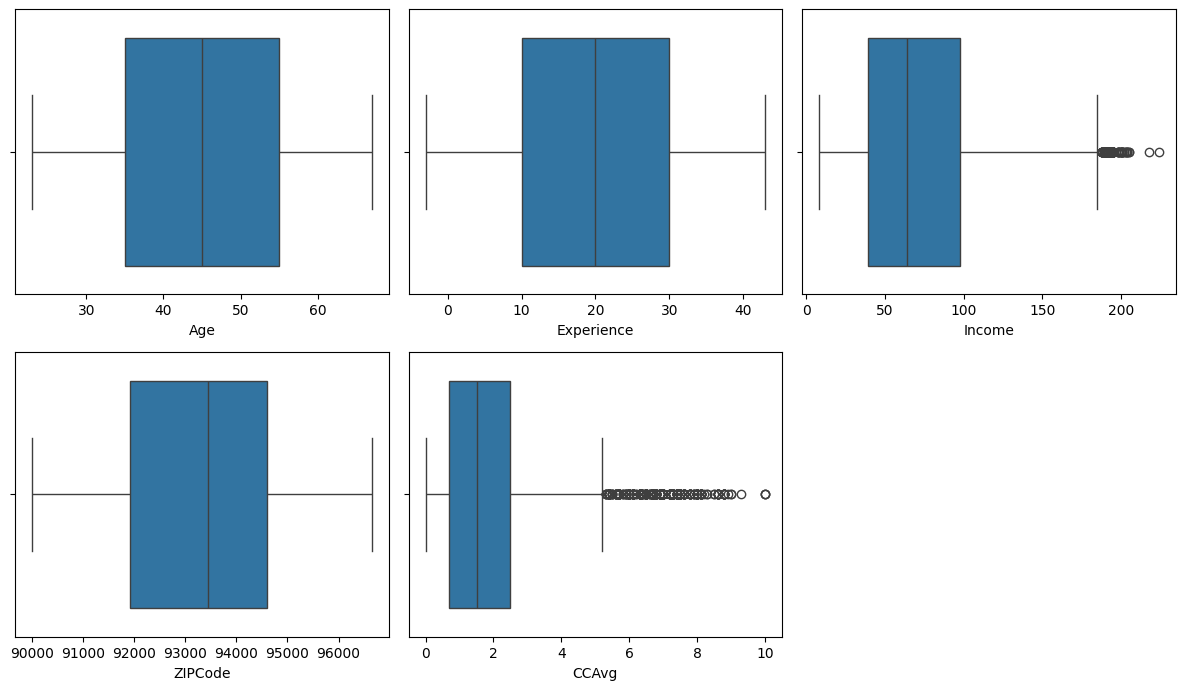

In [20]:
# defining the figure size
plt.figure(figsize=(12, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(['Age','Experience','Income','ZIPCode', 'CCAvg']):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the boxplot

plt.tight_layout();   # to add spacing between plots

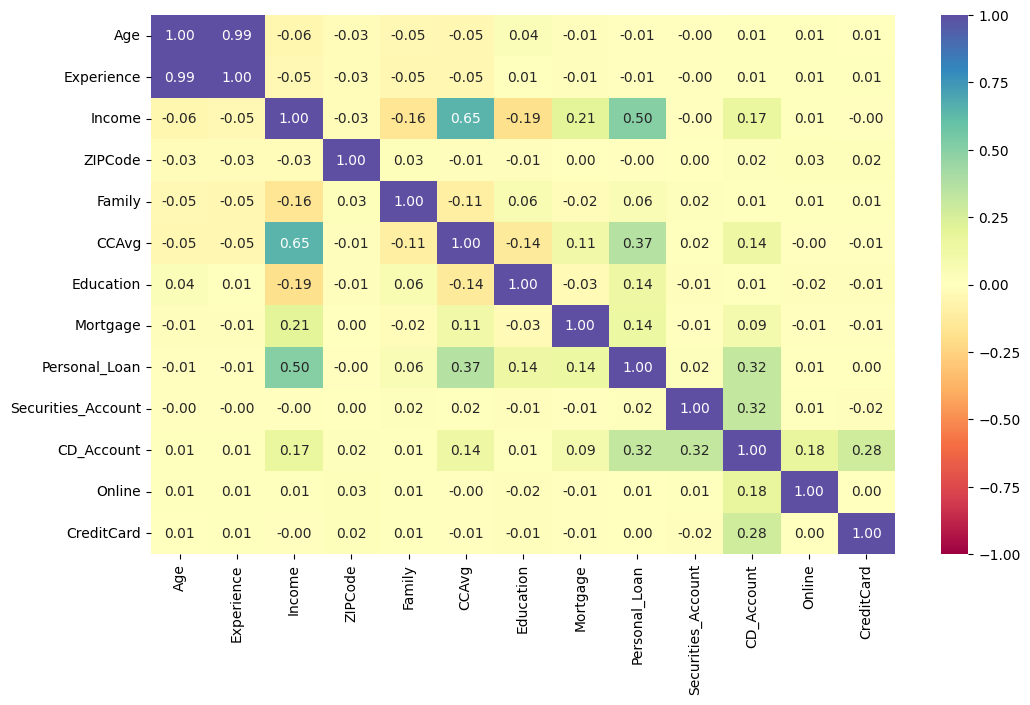

In [22]:
# defining the size of the plot
plt.figure(figsize=(12, 7))
# plotting the heatmap for correlation
sns.heatmap(
    data.corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

Since the target variable is 'Personal_Loan', we should study the variables that predict it best. From the heatmap, five variables have a medium to high correlation with Personal_Loan.

<Axes: xlabel='Income', ylabel='CCAvg'>

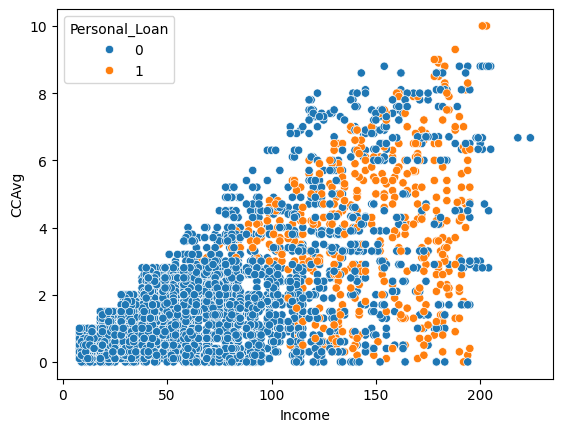

In [54]:
sns.scatterplot(data=data, x='Income', y='CCAvg', hue='Personal_Loan')
#

<Axes: xlabel='Education', ylabel='count'>

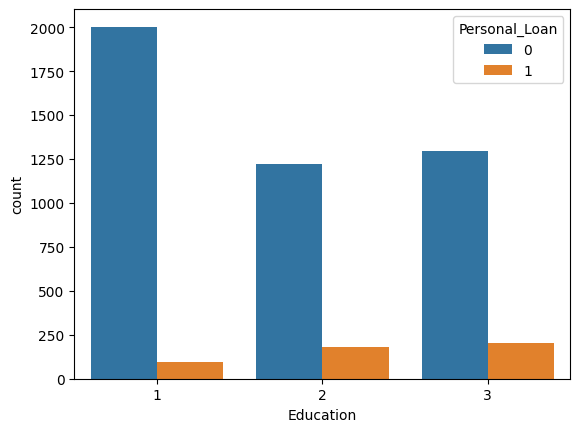

In [60]:
sns.countplot(data=data, x='Education', hue='Personal_Loan')
#

<Axes: xlabel='CD_Account', ylabel='count'>

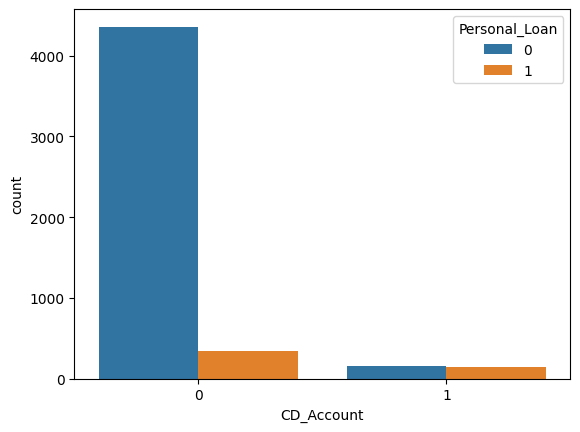

In [64]:
sns.countplot(data=data, x='CD_Account', hue='Personal_Loan')

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [26]:
#Initialise the scaler object
scaler = StandardScaler()

# Fit the scaler to the numerical columns, transform them (i.e., execute the scaling), and create a new dataframe with scaled data
scaled_data = pd.DataFrame(scaler.fit_transform(data))

# Display the scaled data
scaled_data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-1.774417,-1.666078,-0.538229,-1.172217,1.397414,-0.193385,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
1,-0.029524,-0.096330,-0.864109,-1.750863,0.525991,-0.250611,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
2,-0.552992,-0.445163,-1.363793,0.881465,-1.216855,-0.536736,-1.049078,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
3,-0.901970,-0.968413,0.569765,0.535869,-1.216855,0.436091,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
4,-0.901970,-1.055621,-0.625130,-1.045461,1.397414,-0.536736,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618,1.549632


In [28]:
scaled_data.describe().T

,count,mean,std,min,25%,50%,75%,max
0,5000.0,-2.131628e-18,1.0001,-1.948906,-0.901970,-0.029524,0.842923,1.889859
1,5000.0,-1.179501e-16,1.0001,-2.014911,-0.881204,-0.009122,0.862960,1.996667
2,5000.0,1.449507e-16,1.0001,-1.428969,-0.755483,-0.212348,0.526315,3.263712
3,5000.0,1.260148e-15,1.0001,-1.798610,-0.715212,0.152189,0.817803,1.979074
4,5000.0,1.001865e-16,1.0001,-1.216855,-1.216855,-0.345432,0.525991,1.397414
5,5000.0,-6.394885e-17,1.0001,-1.108987,-0.708412,-0.250611,0.321641,4.613525
6,5000.0,2.557954e-17,1.0001,-1.049078,-1.049078,0.141703,1.332484,1.332484
7,5000.0,-5.613288e-17,1.0001,-0.555524,-0.555524,-0.555524,0.437558,5.688108
8,5000.0,-4.973799e-17,1.0001,-0.325875,-0.325875,-0.325875,-0.325875,3.068659
9,5000.0,-2.273737e-17,1.0001,-0.341423,-0.341423,-0.341423,-0.341423,2.928915


Dimensionality reduction and visualisation in 2D

In [29]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(scaled_data)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions

In [30]:
tsne_2d_data.head()

,Feature 1,Feature 2
0,44.828434,-30.708828
1,46.822346,-31.698467
2,15.133970,-31.450279
3,11.696968,-54.043312
4,29.515373,15.664827


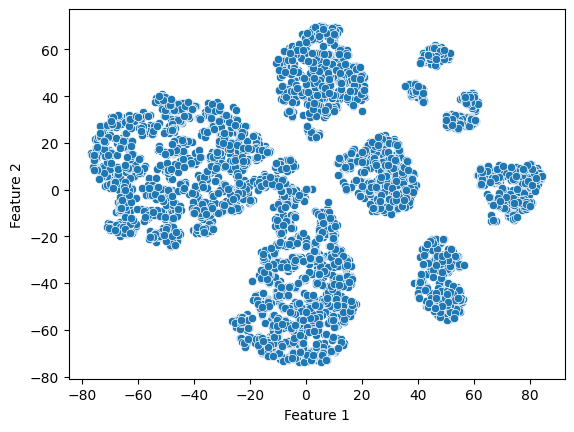

In [31]:
sns.scatterplot(data=tsne_2d_data, x="Feature 1", y="Feature 2");

We can see about 6-9 clusters depending on how we choose to group them.

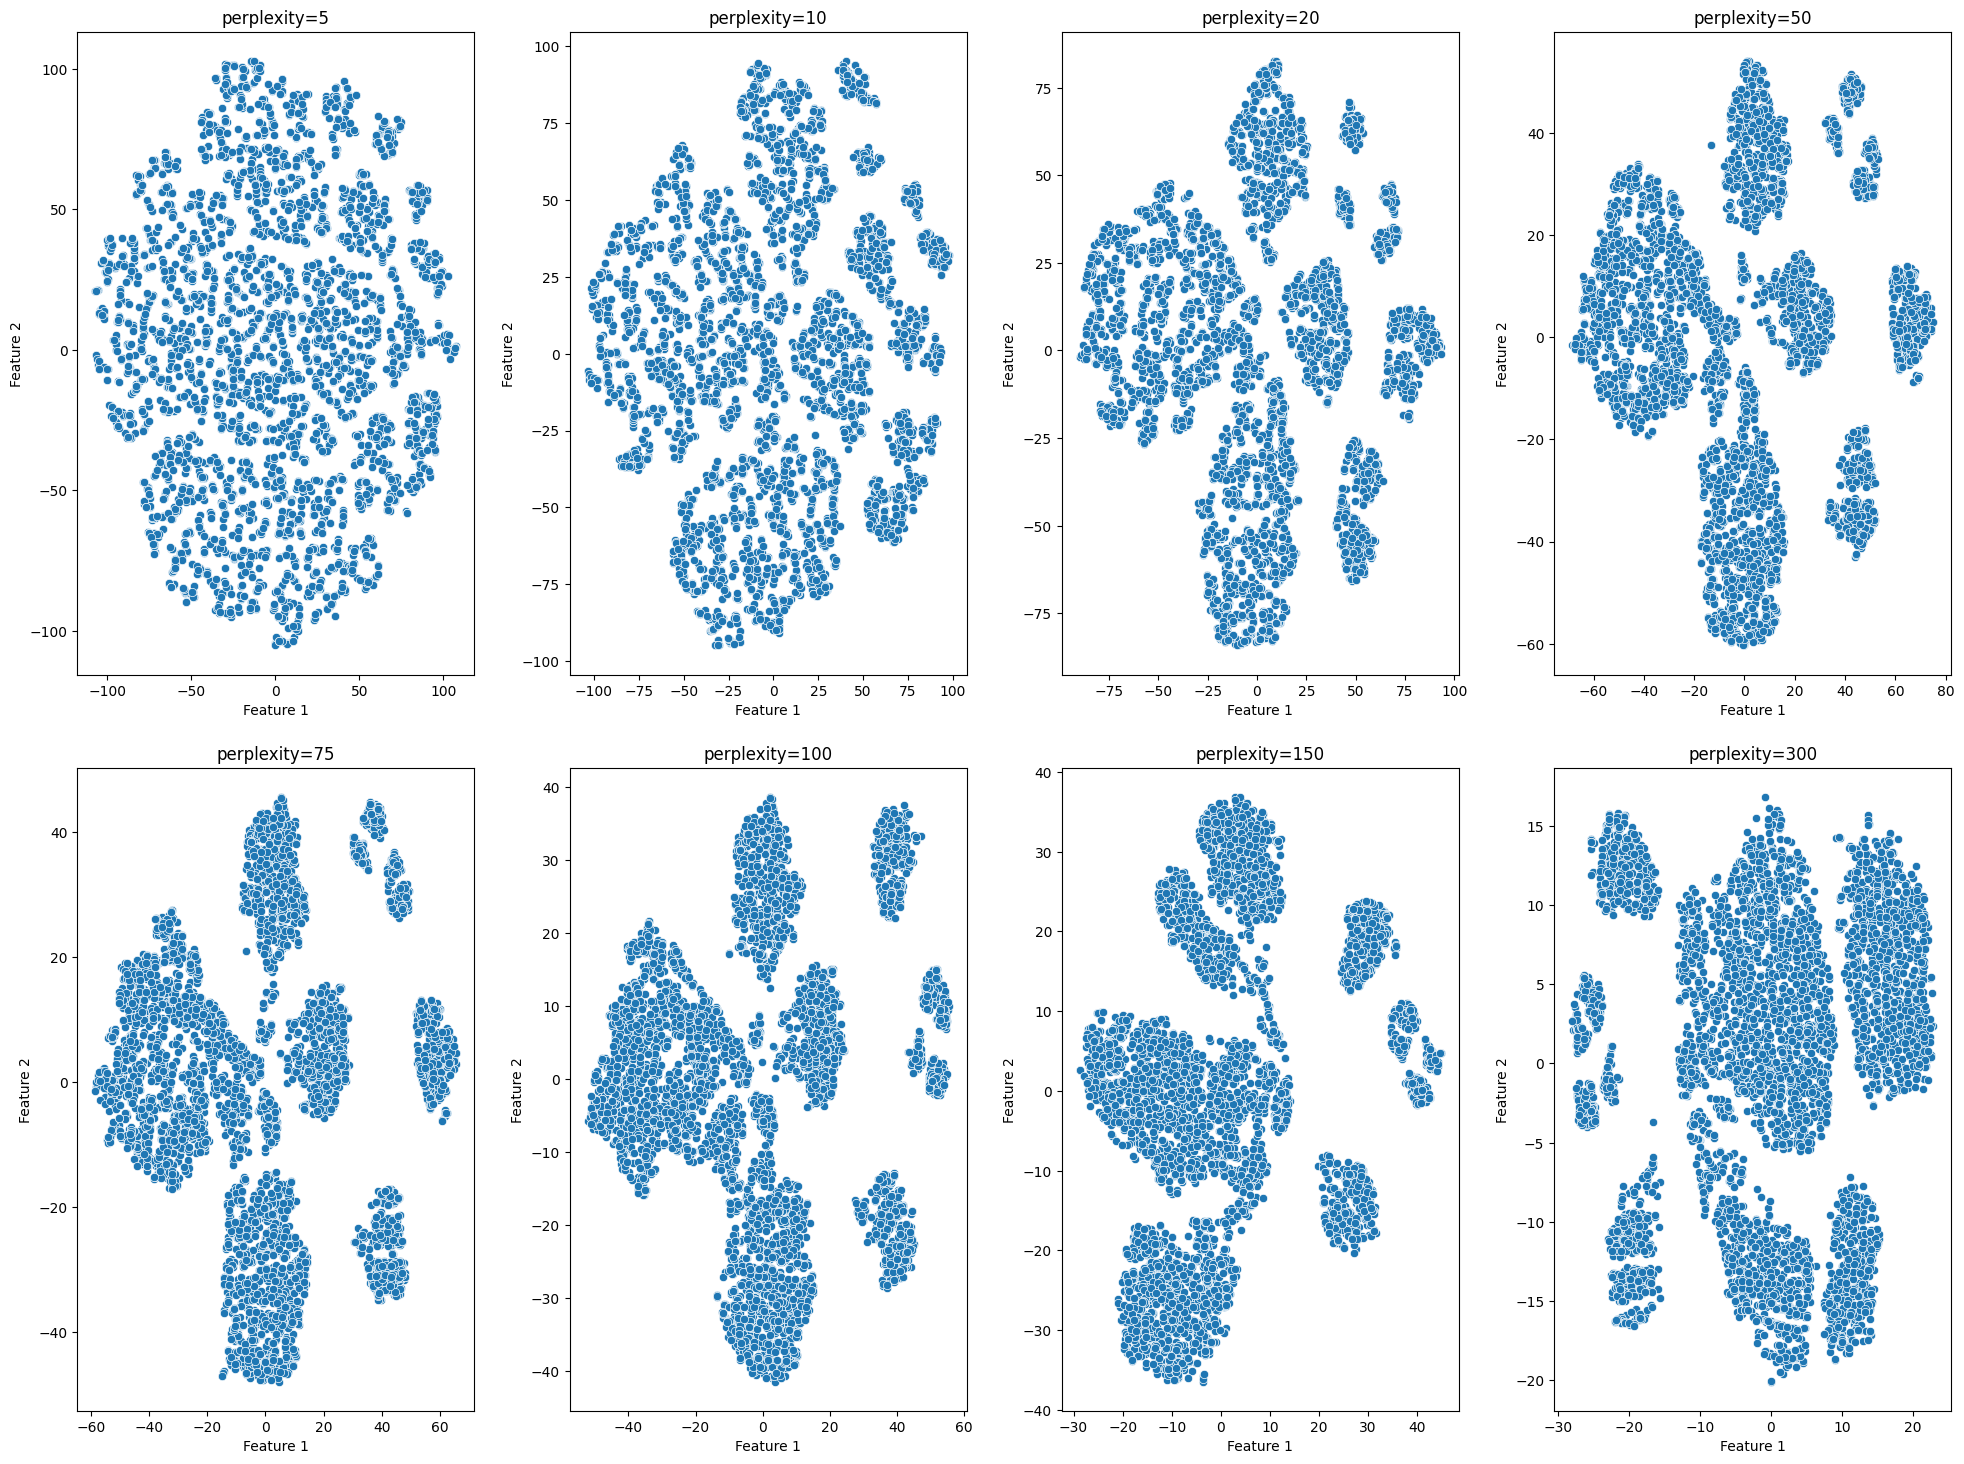

In [33]:
# Define the list of perplexity values to iterate over
perplexities = [5, 10, 20, 50, 75, 100, 150, 300]

plt.figure(figsize=(20, 15))

# Iterate over each perplexity value
for i in range(len(perplexities)):
    # Initiate TSNE with the current perplexity value
    tsne = TSNE(n_components=2, perplexity=perplexities[i], n_jobs=-2, random_state=RS)    # n_jobs specifies the nunmber of cores to use for parallel computation; -2 means use all but 1 core
    X_red = tsne.fit_transform(scaled_data)    # fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
    red_data_df = pd.DataFrame(data=X_red, columns=["Feature 1", "Feature 2"])    # creating a new dataframe with reduced dimensions

    # Adjust the subplot grid to 2x4
    plt.subplot(2, 4, i + 1)

    plt.title("perplexity=" + str(perplexities[i]))    # setting plot title
    sns.scatterplot(data=red_data_df, x="Feature 1", y="Feature 2")
    plt.tight_layout(pad=2)

plt.show()

## Model Building

### Model Evaluation Criterion

*


### Model Building

In [49]:
# create a K-means object
n_clusters = 5
Kmeans_5 = KMeans(n_clusters=n_clusters, random_state=RS)

# fitting the model to the data
Kmeans_5.fit(scaled_data)

KMeans(n_clusters=5, random_state=0)

In [50]:
# Calculate the WCSS (Within-Cluster Sum of Squares)
wcss_k5 = Kmeans_5.inertia_

# Print the WCSS
print("WCSS for K={} is {}".format(n_clusters, wcss_k5))

WCSS for K=5 is 43446.38568250827


In [51]:
# Calculate the silhouette score
sil_score_k5 = silhouette_score(scaled_data, Kmeans_5.labels_)

# Print the silhouette score
print("Silhouette score for K={} is {}".format(n_clusters, sil_score_k5))

Silhouette score for K=5 is 0.11598612996693719


In [52]:
# Assigning cluster labels to the tsne_2d_data DataFrame
tsne_2d_data['Clusters'] = Kmeans_5.labels_
tsne_2d_data.head()

,Feature 1,Feature 2,Clusters
0,44.828434,-30.708828,4
1,46.822346,-31.698467,0
2,15.133970,-31.450279,4
3,11.696968,-54.043312,4
4,29.515373,15.664827,4


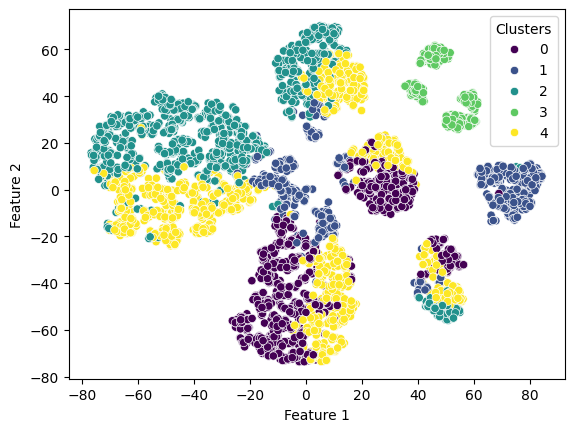

In [53]:
sns.scatterplot(tsne_2d_data, x='Feature 1', y='Feature 2', hue='Clusters', palette='viridis');

## Model Performance Improvement

## Model Performance Comparison and Final Model Selection

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

___